In [5]:
import numpy as np
import pandas as pd

import yfinance as yf
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [3]:
!pip3 install yfinance

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 6.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 8.0 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.8 MB/s  0:00:01 eta 0:00:01
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15635 sha256=6c6f43574e550ac63f20fabc14f536fd94c496145037bbcde002c4253ad178a9
  Stored in directory: /Users/neharavula/Library/Caches/pip/wheels/1e/df/0f/e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [yfinance]/20 [beautifulsoup4]


[*********************100%***********************]  1 of 1 completed


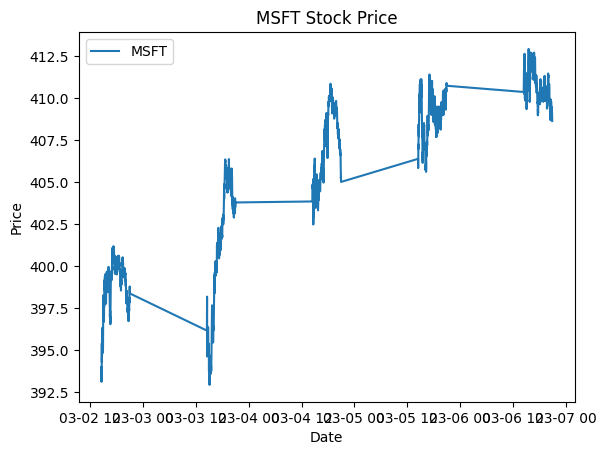

In [6]:
data = yf.download("MSFT", start="2026-03-01", end="2026-03-08", interval="1m");
closedata = data["Close"];
plt.plot(closedata)
plt.title("MSFT Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(["MSFT"])



[*********************100%***********************]  1 of 1 completed


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

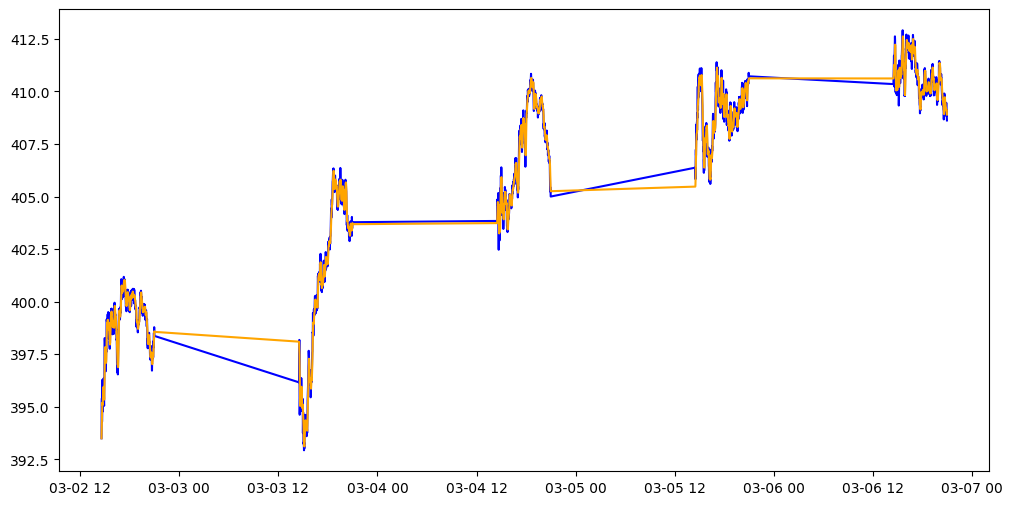

In [23]:
import yfinance as yf
import matplotlib.pyplot as plt

# 1️⃣ Download MSFT 1-minute data
data = yf.download("MSFT", start="2026-03-01", end="2026-03-08", interval="1m")

# 2️⃣ Pick the 'Close' column as a Series
close = data["Close"]  # ✅ Series, NOT DataFrame

# 3️⃣ Compute 5-point moving average
MAVG = close.rolling(window=5).mean()

# 4️⃣ Keep only valid points (drop NaNs from rolling mean)
valid_idx = MAVG.notna()
close_valid = close[valid_idx]
MAVG_valid = MAVG[valid_idx]

# 5️⃣ Compute deviation and outliers
deviation = (close_valid - MAVG_valid) / MAVG_valid
outliers = deviation.abs() > 0.15  # ✅ boolean Series

# 6️⃣ Plot
plt.figure(figsize=(12,6))

# Original series
plt.plot(close_valid.index, close_valid, label="Original", color="blue")

# Moving average
plt.plot(MAVG_valid.index, MAVG_valid, label="5-point Moving Avg", color="orange")

# Scatter only outlier points
plt.scatter(close_valid.index[outliers.values],   # convert boolean Series to NumPy array
            close_valid.values[outliers.values],
            color="red", label="Outliers (>15%)", zorder=5)

plt.title("Rolling Mean and Outlier Detection (15% Threshold)")
plt.legend()
plt.grid(True)
plt.show()